In [1]:
# @title
import pandas as pd
df= pd.read_csv(r"Rail_Fracture_all_5-06-2026.csv",low_memory=False)

In [2]:
df['Kilometerage'] = df['KM'] + (df['METER'] / 1000)
df['Kilometerage'] = df['Kilometerage'].round(3)

# Build combined datetime string and normalize separators; dates are day/month/year
combined_str = (
    df['FRACTURE_DATE'].astype(str).str[:10].str.strip()
    + ' '
    + df['FRACTURE_TIME'].astype(str).str.replace('.', ':', regex=False).str.strip()
)

# Parse using dayfirst=True to handle D/M/YYYY format reliably
df['FRACTURE_TIMESTAMP'] = pd.to_datetime(
    combined_str,
    dayfirst=True,
    errors='coerce'
)

# Safely drop columns if they exist
df = df.drop(columns=[
    'ASSETTYPE',
    'KM',
    'METER',
    'FRACTURE_DATE',
    'FRACTURE_TIME',
], errors='ignore')

# Parse USFDTESTDATE with dayfirst=True as well
df['USFDTIMESTAMP'] = pd.to_datetime(
    df['USFDTESTDATE'],
    dayfirst=True,
    errors='coerce'
)
df = df.drop(columns=['USFDTESTDATE'], errors='ignore')


In [3]:
df.sample(4)

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP
9685,SECR,BSP,CPH-BSP,UP,60KG,86.99,130,1/2/2013,594.30,GR,RR,22.32,LWR,STRAIGHT,1.0,703.657,2020-07-20 10:00:00,2020-07-12
3262,ECR,SPJ,NKE-CPJ,SL,52KG,18.59,110,1/4/1999,307.26,GR,RR,22.9,LWR,STRAIGHT,4.0,301.153,2017-11-14 09:30:00,2017-07-28
8107,NWR,JP,BKIJP,DN,52KG,20.86,130,1/2/2020,24.11,GR,LR,22.9,LWR,STRAIGHT,3.0,224.451,2020-12-27 06:00:00,2020-11-24
1816,ECOR,SBP,SBP-TIG,DN,60KG,18.40,110,1/7/2005,387.36,GR,RR,25,SWR,STRAIGHT,3.0,578.716,2017-10-03 15:20:00,2017-07-27


In [4]:
df.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT',
       'SPEED', 'LAYINGDATE', 'GMTCARRIED', 'USFDCLASSIFICATION', 'LRRR',
       'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'TESTING_FREQ',
       'Kilometerage', 'FRACTURE_TIMESTAMP', 'USFDTIMESTAMP'],
      dtype='object')

In [5]:
# convert LAYINGDATE to datetime (dayfirst=True since dates are in D/M/YYYY format)
df['LAYINGDATE'] = pd.to_datetime(df['LAYINGDATE'], dayfirst=True, errors='coerce')

# ensure FRACTURE_TIMESTAMP is datetime (no-op if already datetime)
df['FRACTURE_TIMESTAMP'] = pd.to_datetime(df['FRACTURE_TIMESTAMP'], errors='coerce')

# compute duration in days as float
df['DURATION'] = (df['FRACTURE_TIMESTAMP'] - df['LAYINGDATE']).dt.total_seconds() / (24 * 60 * 60)


In [6]:
df["USFD_DURATION"] = df["USFDTIMESTAMP"] - df["LAYINGDATE"]
df["USFD_DURATION"] = (
    df["USFD_DURATION"]
      .astype(str)
      .str.replace(" days", "", regex=False)
      .str.strip()
      .astype(float)
)
df.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP,DURATION,USFD_DURATION
9688,SECR,BSP,CPH-BSP,UP,60KG,86.990,130,2018-07-01,205.94,GR,LR,22.32,SWR,STRAIGHT,1.0,712.840,2020-12-15 13:30:00,2020-11-26,898.562500,879.0
2845,ECR,DNR,RGD-TIA,SL,60KG,23.924,50,2010-06-01,82.00,GR,RR,22.32,LWR,STRAIGHT,3.0,41.178,2023-12-19 07:00:00,2023-08-13,4949.291667,4821.0
11455,WR,BRC,ND-ADI,UP,60KG,64.180,130,2020-07-01,65.33,GR,RR,22.9,LWR,STRAIGHT,2.0,473.214,2022-08-01 08:15:00,2022-06-23,761.343750,722.0
6676,NR,MB,BLM-RAC,DN,52KG,26.300,110,2000-04-01,264.31,GR,LR,22.9,LWR,STRAIGHT,3.0,1199.082,2014-12-03 05:40:00,2014-07-14,5359.236111,5217.0
8057,NWR,JP,AWR-BKI,DN,52KG,13.550,130,2004-01-01,348.89,GR,LR,22.9,LWR,STRAIGHT,6.0,97.255,2019-10-08 08:25:00,2019-09-24,5759.350694,5745.0


In [7]:
df[df.USFD_DURATION <= 0].sample(5)


,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,LRRR,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP,DURATION,USFD_DURATION
6748,NR,MB,BLM-RAC,DN,52KG,27.17,110,2015-11-01,288.00,GR,RR,22.9,LWR,STRAIGHT,3.0,1177.674,2015-12-02 04:00:00,2015-10-08,31.166667,-24.0
1465,ECOR,KUR,ROP-JKPR,UP,60KG,27.02,130,2013-08-01,46.41,GR,RR,25,LWR,STRAIGHT,2.0,305.098,2015-01-18 02:15:00,2013-04-02,535.093750,-121.0
11113,SWR,SBC,OML-LOGH,SL,52KG,9.39,110,2016-01-01,2.32,GR,RR,22.9,LWR,STRAIGHT,6.0,167.424,2016-05-08 15:40:00,2015-11-19,128.652778,-43.0
3097,ECR,SEE,KGG-BJU,UP,52KG,13.41,110,2017-01-01,5.57,GR,LR,22.9,LWR,CURVE,4.0,135.111,2017-02-02 08:25:00,2016-11-21,32.350694,-41.0
7959,NWR,AII,FL AII,UP,60KG,16.34,130,2021-01-01,1.95,GR,LR,22.9,LWR,CURVE,6.0,291.045,2021-02-05 01:45:00,2020-12-25,35.072917,-7.0


In [8]:
df[df.USFD_DURATION <= 0].count()

RLYCODE               54
DIVCODE               54
SECTION               54
LINE                  54
RAIL_SECTION          54
ANNUAL_GMT            54
SPEED                 54
LAYINGDATE            54
GMTCARRIED            54
USFDCLASSIFICATION    54
LRRR                  54
AXLELOAD              54
TRACK_TYPE            54
STRAIGHT_CURVE        54
TESTING_FREQ          54
Kilometerage          54
FRACTURE_TIMESTAMP    54
USFDTIMESTAMP         54
DURATION              54
USFD_DURATION         54
dtype: int64

In [9]:
mask = (
    (df["USFD_DURATION"] <= 0) |
    (df["USFD_DURATION"].isna())
)

print("Rows to repair:", mask.sum())

# Duration inferred from GMT
gmt_duration_days = (
    df.loc[mask, "GMTCARRIED"] /
    df.loc[mask, "ANNUAL_GMT"]
) * 365.25

# Reconstruct laying date
df.loc[mask, "LAYING_DATE_GMT"] = (
    df.loc[mask, "FRACTURE_TIMESTAMP"] -
    pd.to_timedelta(gmt_duration_days, unit="D")
)

# Calculate candidate duration
candidate_duration = (
    df.loc[mask, "USFDTIMESTAMP"] -
    df.loc[mask, "LAYING_DATE_GMT"]
).dt.days

# Keep only non-negative durations
valid_mask = candidate_duration >= 0

df.loc[candidate_duration.index[valid_mask], "USFD_DURATION"] = (
    candidate_duration[valid_mask]
)

print("Remaining invalid values:",
      ((df["USFD_DURATION"] <= 0) | df["USFD_DURATION"].isna()).sum())

df.loc[
    candidate_duration.index[valid_mask],
    ["USFDTIMESTAMP", "LAYING_DATE_GMT", "USFD_DURATION"]
].head()

Rows to repair: 54
Remaining invalid values: 21


,USFDTIMESTAMP,LAYING_DATE_GMT,USFD_DURATION
75,2020-09-25,1999-02-04 22:30:04.414715801,7903.0
306,2017-04-27,2016-06-11 13:34:26.588921281,319.0
307,2017-04-27,2016-07-20 14:34:26.588921281,280.0
619,2020-05-11,2017-07-03 05:59:06.857142863,1042.0
1010,2021-02-04,2011-11-17 11:31:25.714285707,3366.0


In [10]:
len(df.SECTION.unique())

721

In [11]:
df.DURATION.describe()

count    11537.000000
mean      4778.502818
std       2652.768895
min         30.850694
25%       2903.437500
50%       4844.274306
75%       6568.333333
max      20538.253472
Name: DURATION, dtype: float64

In [12]:
df[df.DURATION <= 0]

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,...,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP,DURATION,USFD_DURATION,LAYING_DATE_GMT


In [13]:
# @title

p75 = df['DURATION'].quantile(0.75)
print("75th Percentile:", p75)
p25 = df['DURATION'].quantile(0.25)
print("25th Percentile:", p25)
iqr = 1.5*(p75-p25)
print("Upper limit:", p75 + iqr)

75th Percentile: 6568.333333333333
25th Percentile: 2903.4375
Upper limit: 12065.677083333332


In [14]:
df[df.DURATION ==0].count

<bound method DataFrame.count of Empty DataFrame
Columns: [RLYCODE, DIVCODE, SECTION, LINE, RAIL_SECTION, ANNUAL_GMT, SPEED, LAYINGDATE, GMTCARRIED, USFDCLASSIFICATION, LRRR, AXLELOAD, TRACK_TYPE, STRAIGHT_CURVE, TESTING_FREQ, Kilometerage, FRACTURE_TIMESTAMP, USFDTIMESTAMP, DURATION, USFD_DURATION, LAYING_DATE_GMT]
Index: []

[0 rows x 21 columns]>

In [15]:
upper = p75 + iqr
df[df.DURATION ==0]

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,...,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP,DURATION,USFD_DURATION,LAYING_DATE_GMT


In [16]:
df = df[df.DURATION > 0]

In [17]:
df.DURATION.describe()

count    11537.000000
mean      4778.502818
std       2652.768895
min         30.850694
25%       2903.437500
50%       4844.274306
75%       6568.333333
max      20538.253472
Name: DURATION, dtype: float64

In [18]:
df = df.rename(columns={'FRACTURE_DATE.1': 'FRACTURE_DATE'})

In [19]:
df.isnull().sum()

RLYCODE                   0
DIVCODE                   0
SECTION                   0
LINE                      0
RAIL_SECTION              0
ANNUAL_GMT              323
SPEED                     0
LAYINGDATE                0
GMTCARRIED               16
USFDCLASSIFICATION        0
LRRR                      0
AXLELOAD                  0
TRACK_TYPE                0
STRAIGHT_CURVE            0
TESTING_FREQ              0
Kilometerage              0
FRACTURE_TIMESTAMP        0
USFDTIMESTAMP             0
DURATION                  0
USFD_DURATION             0
LAYING_DATE_GMT       11483
dtype: int64

In [20]:
df.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'ANNUAL_GMT',
       'SPEED', 'LAYINGDATE', 'GMTCARRIED', 'USFDCLASSIFICATION', 'LRRR',
       'AXLELOAD', 'TRACK_TYPE', 'STRAIGHT_CURVE', 'TESTING_FREQ',
       'Kilometerage', 'FRACTURE_TIMESTAMP', 'USFDTIMESTAMP', 'DURATION',
       'USFD_DURATION', 'LAYING_DATE_GMT'],
      dtype='object')

In [21]:
len(df)

11537

In [22]:
df['DURATION'].quantile(0.95)

9045.459027777777

In [23]:
df.DURATION.describe()

count    11537.000000
mean      4778.502818
std       2652.768895
min         30.850694
25%       2903.437500
50%       4844.274306
75%       6568.333333
max      20538.253472
Name: DURATION, dtype: float64

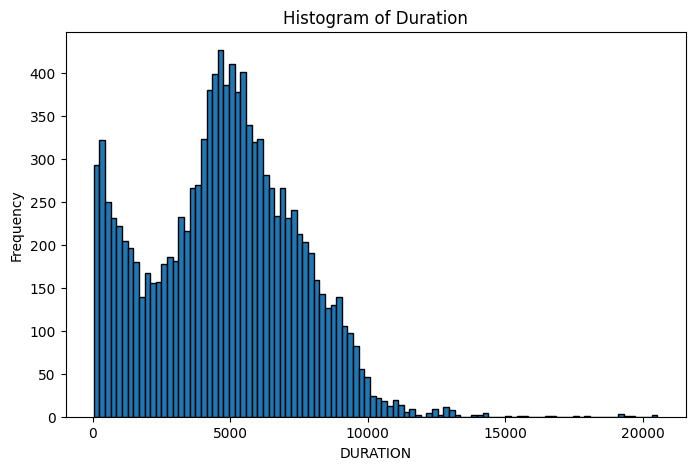

In [24]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [25]:
print(df['DURATION'].describe())

count    11537.000000
mean      4778.502818
std       2652.768895
min         30.850694
25%       2903.437500
50%       4844.274306
75%       6568.333333
max      20538.253472
Name: DURATION, dtype: float64


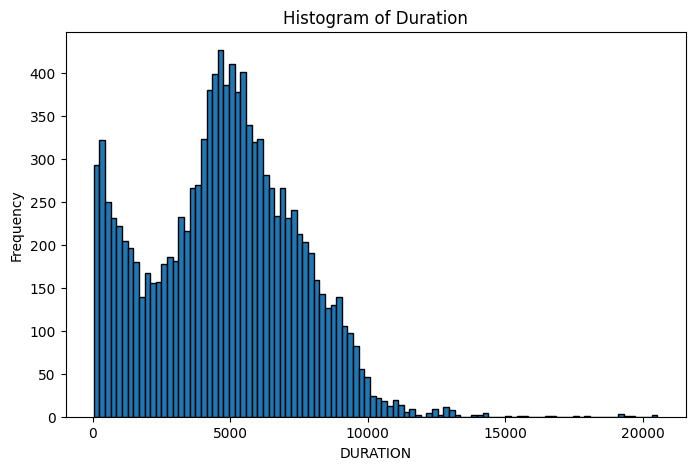

In [26]:
import matplotlib.pyplot as plt

# assuming df is your DataFrame
plt.figure(figsize=(8,5))
plt.hist(df["DURATION"], bins=100, edgecolor="black")
plt.xlabel("DURATION")
plt.ylabel("Frequency")
plt.title("Histogram of Duration")
plt.show()

In [27]:
df['SECTION'].value_counts()

SECTION
KUR-NWP     322
BE-MB       295
MB-NBD      237
BRKA-GHD    208
PNBE-ARA    177
           ... 
BKNM-AMZ      1
BT-PTPL       1
RGX-HLZ       1
BLN-BGB       1
UJN-MKC       1
Name: count, Length: 721, dtype: int64

In [28]:
df['LINE'].value_counts()

LINE
UP                 4910
DN                 4897
SL                 1011
MID                  85
DN Harbour Line      75
UP Harbour Line      65
IIIrd Line           58
DN 1                 45
Rev Line             41
N                    36
A Line               35
S                    31
DN 2                 24
IVth Line            23
UP 2                 23
Slow Line DN         22
UP 1                 21
DAL UP               18
Slow Line UP         14
GAL UP               12
DAL DN               12
GAL DN               10
WL                    8
EMU UP Line           7
OML                   7
5th line              6
UD line               5
EMU DN Line           5
Dn Suburban           5
Up Chord              4
IInd Line             4
Up Suburban           3
B Line                3
Ist Line              2
EMU Line              2
Dn Chord              2
Common                2
6th line              2
Common-2              1
EL                    1
Name: count, dtype: int64

In [29]:
# @title
def reduce_line(line):
    if line in ["DN","DN 1", "DN 2"]:
        return "DN"
    elif line in ["SL", "IIIrd Line", "IVth Line", "MID"]:
        return "SL"
    elif line in ["UP 1", "UP 2","UP"]:
        return "UP"
    else:
        return "OT"

df["LINE"] = df["LINE"].apply(reduce_line)
df["LINE"].value_counts()


LINE
DN    4966
UP    4954
SL    1177
OT     440
Name: count, dtype: int64

In [30]:
# df =df[df['RAIL_SECTION']!= 'OTHER']

In [31]:
df.RAIL_SECTION.value_counts()

RAIL_SECTION
52KG     6510
60KG     5023
OTHER       4
Name: count, dtype: int64

In [32]:
df['USFDCLASSIFICATION'].value_counts()

USFDCLASSIFICATION
GR                   11214
OBS Joggled Plate      301
OBS                     20
IMR                      2
Name: count, dtype: int64

In [33]:
# Rename category
df["USFDCLASSIFICATION"] = df["USFDCLASSIFICATION"].replace(
    {"OBS Joggled Plate": "OBS"}
)

# Keep only GR, OBS, IMR
df = df[df["USFDCLASSIFICATION"].isin(["GR", "OBS", "IMR"])]

# Check result
print(df["USFDCLASSIFICATION"].value_counts())

USFDCLASSIFICATION
GR     11214
OBS      321
IMR        2
Name: count, dtype: int64


In [34]:
# @title
import numpy as np
import re

def clean_axle_load(x):
    if pd.isna(x):
        return np.nan

    # Convert to string
    x = str(x).strip()

    # Handle ranges like "Up to 20.32"
    if "up to" in x.lower():
        num = re.findall(r"\d+\.?\d*", x)
        return int(round(float(num[0]))) if num else np.nan

    # Extract numeric part
    num = re.findall(r"\d+\.?\d*", x)
    if num:
        return int(round(float(num[0])))

    return np.nan


df["AXLELOAD"] = df["AXLELOAD"].apply(clean_axle_load)

df['AXLELOAD'].value_counts()

AXLELOAD
23    5310
22    4328
25    1786
20     113
Name: count, dtype: int64

In [35]:
mask = df["RAIL_SECTION"] != "OTHER"

df.loc[mask, "RAIL_SECTION"] = (
    df.loc[mask, "RAIL_SECTION"]
      .astype(str)
      .str.replace("KG", "", regex=False)
      .astype(int)
)

In [36]:
df['RAIL_SECTION'].value_counts()

RAIL_SECTION
52       6510
60       5023
OTHER       4
Name: count, dtype: int64

Encoding

In [37]:
# @title
# Identify all object dtype columns (for reference)
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)

# Encoding strategy:
#   Binary Encoding  → SECTION, RLYCODE, DIVCODE  (high cardinality)
#   Ordinal Encoding → USFDCLASSIFICATION         (GR=0, OBS=1, IMR=2)
#   One-Hot Encoding → LINE, LRRR, TRACK_TYPE, STRAIGHT_CURVE  (low cardinality)


Categorical columns: ['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'USFDCLASSIFICATION', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE']


In [38]:
p95 = df['DURATION'].quantile(0.99)
print("95th Percentile:", p95)

95th Percentile: 10717.46555555555


In [39]:
df['AXLELOAD'].unique()

array([22, 23, 25, 20], dtype=int64)

***Modeling***

In [40]:
axleload_map = {20: 1, 22: 2, 23: 3, 25: 4}
df['AXLELOAD'] = df['AXLELOAD'].map(axleload_map)
print(df[['AXLELOAD', 'AXLELOAD']].head())
rail_map = { 52: 1,60: 2}
df["RAIL_SECTION"] = df["RAIL_SECTION"].map(rail_map)

   AXLELOAD  AXLELOAD
0         2         2
1         2         2
2         2         2
3         2         2
4         2         2


In [41]:
df.sample(5)

,RLYCODE,DIVCODE,SECTION,LINE,RAIL_SECTION,ANNUAL_GMT,SPEED,LAYINGDATE,GMTCARRIED,USFDCLASSIFICATION,...,AXLELOAD,TRACK_TYPE,STRAIGHT_CURVE,TESTING_FREQ,Kilometerage,FRACTURE_TIMESTAMP,USFDTIMESTAMP,DURATION,USFD_DURATION,LAYING_DATE_GMT
3501,ER,ASN,KAN-UDL,UP,1.0,17.48,130,1993-03-01,711.12,GR,...,2,LWR,STRAIGHT,4.0,170.149,2019-11-20 03:10:00,2019-09-02,9760.131944,9681.0,NaT
6223,NR,LKO,UTR-LKO,DN,1.0,27.90,110,2003-02-01,370.94,GR,...,2,LWR,STRAIGHT,4.0,1070.803,2014-10-10 03:10:00,2014-09-18,4269.131944,4247.0,NaT
2490,ECR,DNR,BKP-FUT,DN,1.0,31.68,130,1995-08-01,588.55,GR,...,2,LWR,STRAIGHT,3.0,507.597,2017-12-14 07:30:00,2017-11-27,8171.312500,8154.0,NaT
4838,NR,DLI,DEC-GHH,UP,1.0,63.61,110,2015-04-01,113.66,GR,...,2,LWR,STRAIGHT,4.0,37.651,2021-01-29 06:20:00,2020-11-13,2130.263889,2053.0,NaT
11446,WR,BRC,MYG-VS,UP,2.0,54.18,130,2016-09-01,151.23,GR,...,2,LWR,STRAIGHT,2.0,374.154,2019-04-18 08:30:00,2019-04-01,959.354167,942.0,NaT


In [42]:
# @title

#df['NEW_GMT'] = (df['DURATION']/365)*df['ANNUAL_GMT']

# df["GMT_NO"] = df["GMT_CARRIED"] /df["ANNUAL_GMT"]
df["ANNUAL_LOAD"] = df["ANNUAL_GMT"] * df["AXLELOAD"]
# Removed: df["AXLELOAD"]  = df["AXLELOAD"].map({22: 1, 23:2}) # This line caused valid AXLELOAD values to become NaN
df["SPEED_AGMT"] = df["SPEED"] * df["ANNUAL_GMT"]

# Consolidate column dropping here after feature engineering
df = df.drop(columns=['LAYINGDATE.1', 'Censoring_date', 'FRACTURE_DATE', 'ANNUAL_GMT', 'Weather_failed'], errors='ignore')

In [43]:
df.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'SPEED',
       'LAYINGDATE', 'GMTCARRIED', 'USFDCLASSIFICATION', 'LRRR', 'AXLELOAD',
       'TRACK_TYPE', 'STRAIGHT_CURVE', 'TESTING_FREQ', 'Kilometerage',
       'FRACTURE_TIMESTAMP', 'USFDTIMESTAMP', 'DURATION', 'USFD_DURATION',
       'LAYING_DATE_GMT', 'ANNUAL_LOAD', 'SPEED_AGMT'],
      dtype='object')

In [44]:
df = df.drop(columns=['LAYING_DATE_GMT', 'LAYINGDATE', 'FRACTURE_TIMESTAMP', 'USFDTIMESTAMP'], errors='ignore')

In [45]:
df.columns

Index(['RLYCODE', 'DIVCODE', 'SECTION', 'LINE', 'RAIL_SECTION', 'SPEED',
       'GMTCARRIED', 'USFDCLASSIFICATION', 'LRRR', 'AXLELOAD', 'TRACK_TYPE',
       'STRAIGHT_CURVE', 'TESTING_FREQ', 'Kilometerage', 'DURATION',
       'USFD_DURATION', 'ANNUAL_LOAD', 'SPEED_AGMT'],
      dtype='object')

In [46]:
print(df['RLYCODE'].unique())

['CR' 'ECOR' 'ECR' 'ER' 'NCR' 'NER' 'NFR' 'NR' 'NWR' 'SCOR' 'SCR' 'SECR'
 'SER' 'SR' 'SWR' 'WCR' 'WR']


## Data Preparation for Modeling

In [47]:
df_model = df.copy()

### Feature and Target Definition

In [48]:
X = df_model.drop('DURATION', axis=1)
y = df_model['DURATION']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (11537, 17)
Target (y) shape: (11537,)


### Train-Test Split

In [49]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9229, 17)
X_test shape: (2308, 17)
y_train shape: (9229,)
y_test shape: (2308,)


In [50]:
median_annual_gmt = X_train['SPEED_AGMT'].median()
X_train['SPEED_AGMT'].fillna(median_annual_gmt, inplace=True)

median_gmtcarried = X_train['GMTCARRIED'].median()
X_train['GMTCARRIED'].fillna(median_gmtcarried, inplace=True)

print("Missing values after imputation:")
print(X_train[['SPEED_AGMT', 'GMTCARRIED']].isnull().sum())

median_annual_gmt = X_test['SPEED_AGMT'].median()
X_test['SPEED_AGMT'].fillna(median_annual_gmt, inplace=True)

median_gmtcarried = X_test['GMTCARRIED'].median()
X_test['GMTCARRIED'].fillna(median_gmtcarried, inplace=True)

print("Missing values after imputation:")
print(X_test[['SPEED_AGMT', 'GMTCARRIED']].isnull().sum())

median_annual_gmt = X_train['ANNUAL_LOAD'].median()
X_train['ANNUAL_LOAD'].fillna(median_annual_gmt, inplace=True)
print("Missing values after imputation:")
print(X_train[['ANNUAL_LOAD']].isnull().sum())
median_annual_gmt = X_test['ANNUAL_LOAD'].median()
X_test['ANNUAL_LOAD'].fillna(median_annual_gmt, inplace=True)
print("Missing values after imputation:")
print(X_test[['ANNUAL_LOAD',]].isnull().sum())

Missing values after imputation:
SPEED_AGMT    0
GMTCARRIED    0
dtype: int64
Missing values after imputation:
SPEED_AGMT    0
GMTCARRIED    0
dtype: int64
Missing values after imputation:
ANNUAL_LOAD    0
dtype: int64
Missing values after imputation:
ANNUAL_LOAD    0
dtype: int64


In [51]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
import category_encoders as ce
import numpy as np

# ================================================================
# ENCODING STRATEGY
# ================================================================
# Binary Encoding  : SECTION, RLYCODE, DIVCODE  (high cardinality)
# Ordinal Encoding : USFDCLASSIFICATION         (GR=0, OBS=1, IMR=2)
# One-Hot Encoding : LINE, LRRR, TRACK_TYPE, STRAIGHT_CURVE
# Standard Scaling : all numeric features
# ================================================================

numerical_features = [
    'RAIL_SECTION', 'SPEED', 'GMTCARRIED', 'AXLELOAD',
    'Kilometerage', 'TESTING_FREQ',
    'ANNUAL_LOAD', 'SPEED_AGMT', 'USFD_DURATION'
]
binary_features  = ['SECTION', 'RLYCODE', 'DIVCODE']
ordinal_features = ['USFDCLASSIFICATION']
ohe_features     = ['LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE']

# ── Step 1: Binary Encoding (fit on train only → no leakage) ─────────────
bin_enc = ce.BinaryEncoder(cols=binary_features, handle_unknown='value')
X_train_bin = bin_enc.fit_transform(X_train[binary_features])
X_test_bin  = bin_enc.transform(X_test[binary_features])

# ── Step 2: Ordinal Encoding for USFDCLASSIFICATION ───────────────────────
usfd_order = [['GR', 'OBS', 'IMR']]   # GR=0, OBS=1, IMR=2
ord_enc = OrdinalEncoder(
    categories=usfd_order,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
X_train_ord = ord_enc.fit_transform(X_train[ordinal_features])
X_test_ord  = ord_enc.transform(X_test[ordinal_features])

# ── Step 3: Attach encoded columns back as DataFrames ────────────────────
bin_cols = X_train_bin.columns.tolist()
ord_col  = ['USFDCLASSIFICATION_ord']

X_train_enc = X_train.copy()
X_test_enc  = X_test.copy()

# Drop original high-card + ordinal columns, attach encoded versions
X_train_enc = X_train_enc.drop(columns=binary_features + ordinal_features, errors='ignore')
X_test_enc  = X_test_enc.drop(columns=binary_features + ordinal_features, errors='ignore')

for col in bin_cols:
    X_train_enc[col] = X_train_bin[col].values
    X_test_enc[col]  = X_test_bin[col].values

X_train_enc['USFDCLASSIFICATION_ord'] = X_train_ord.flatten()
X_test_enc['USFDCLASSIFICATION_ord']  = X_test_ord.flatten()

# ── Step 4: ColumnTransformer — scale numeric, OHE low-cardinality ────────
num_feats = [c for c in numerical_features if c in X_train_enc.columns]
ohe_feats = [c for c in ohe_features      if c in X_train_enc.columns]

# Binary-encoded columns are already numeric — add to num_feats for scaling
all_num_feats = num_feats + ['USFDCLASSIFICATION_ord'] + bin_cols
all_num_feats = [c for c in all_num_feats if c in X_train_enc.columns]

x_mapper = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(),                                  all_num_feats),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False),                ohe_feats),
    ],
    remainder='drop'
)

x_train_transformed = x_mapper.fit_transform(X_train_enc)
x_test_transformed  = x_mapper.transform(X_test_enc)

print(f"x_train_transformed shape: {x_train_transformed.shape}")
print(f"x_test_transformed  shape: {x_test_transformed.shape}")
print(f"\nBinary-encoded columns ({len(bin_cols)}): {bin_cols}")
print(f"OHE columns: {ohe_feats}")


x_train_transformed shape: (9229, 43)
x_test_transformed  shape: (2308, 43)

Binary-encoded columns (22): ['SECTION_0', 'SECTION_1', 'SECTION_2', 'SECTION_3', 'SECTION_4', 'SECTION_5', 'SECTION_6', 'SECTION_7', 'SECTION_8', 'SECTION_9', 'RLYCODE_0', 'RLYCODE_1', 'RLYCODE_2', 'RLYCODE_3', 'RLYCODE_4', 'DIVCODE_0', 'DIVCODE_1', 'DIVCODE_2', 'DIVCODE_3', 'DIVCODE_4', 'DIVCODE_5', 'DIVCODE_6']
OHE columns: ['LINE', 'LRRR', 'TRACK_TYPE', 'STRAIGHT_CURVE']


In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import ParameterGrid, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tqdm import tqdm
import numpy as np

print("Starting CPU Grid Search...")

# ==========================================================
# NaN HANDLING
# ==========================================================

if hasattr(x_train_transformed, 'toarray'):
    x_train_transformed_dense = x_train_transformed.toarray()
else:
    x_train_transformed_dense = x_train_transformed

if hasattr(x_test_transformed, 'toarray'):
    x_test_transformed_dense = x_test_transformed.toarray()
else:
    x_test_transformed_dense = x_test_transformed

nan_rows_train = np.isnan(x_train_transformed_dense).any(axis=1)
x_train_transformed_clean = x_train_transformed_dense[~nan_rows_train]
y_train_clean = y_train[~nan_rows_train]

nan_rows_test = np.isnan(x_test_transformed_dense).any(axis=1)
x_test_transformed_clean = x_test_transformed_dense[~nan_rows_test]
y_test_clean = y_test[~nan_rows_test]

print(f"Original training samples : {len(y_train)}, cleaned: {len(y_train_clean)}")
print(f"Original test samples     : {len(y_test)}, cleaned: {len(y_test_clean)}")

# ==========================================================
# PARAMETER GRID
# ==========================================================

param_grid = {
    "n_estimators": [200],
    "max_depth": [50],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

# Uncomment for a larger search space

'''param_grid = {
    "n_estimators":      [200, 300, 500, 700],
    "max_depth":         [10, 20, 30, 50],
    "min_samples_split": [2, 3, 5, 7, 10],
    "min_samples_leaf":  [1, 2, 4, 6, 8],
    "max_features":      ["sqrt"],
    "bootstrap":         [True]
}'''


# ==========================================================
# GRID SEARCH WITH 5-FOLD CV
# ==========================================================

all_params = list(ParameterGrid(param_grid))
total_combos = len(all_params)

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

best_score = np.inf
best_params = None

with tqdm(
    total=total_combos,
    desc="Grid Search",
    unit="combo",
    bar_format="{l_bar}{bar:30}{r_bar}"
) as pbar:

    for params in all_params:

        rf = RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )

        fold_rmses = []

        for train_idx, val_idx in kf.split(x_train_transformed_clean):

            X_tr = x_train_transformed_clean[train_idx]
            X_val = x_train_transformed_clean[val_idx]

            y_tr = y_train_clean.iloc[train_idx]
            y_val = y_train_clean.iloc[val_idx]

            rf.fit(X_tr, y_tr)

            preds = rf.predict(X_val)

            fold_rmse = np.sqrt(
                mean_squared_error(y_val, preds)
            )

            fold_rmses.append(fold_rmse)

        mean_rmse = np.mean(fold_rmses)

        if mean_rmse < best_score:
            best_score = mean_rmse
            best_params = params

        pbar.set_postfix(
            best_rmse=f"{best_score:.4f}",
            current_rmse=f"{mean_rmse:.4f}"
        )

        pbar.update(1)

print("\n================================================")
print("BEST MODEL RESULTS")
print("================================================")
print("Best Parameters:")
print(best_params)
print(f"\nBest CV RMSE: {best_score:.4f}")

# ==========================================================
# TRAIN BEST MODEL ON FULL TRAINING DATA
# ==========================================================

best_rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1,
    **best_params
)

print("\nTraining best model on full training set...")

with tqdm(
    total=1,
    desc="Final Training",
    bar_format="{l_bar}{bar:30}{r_bar}"
) as pbar:

    best_rf.fit(
        x_train_transformed_clean,
        y_train_clean
    )

    pbar.update(1)

# ==========================================================
# TEST SET PERFORMANCE
# ==========================================================

y_pred = best_rf.predict(x_test_transformed_clean)

rmse = np.sqrt(
    mean_squared_error(y_test_clean, y_pred)
)

mae = mean_absolute_error(
    y_test_clean,
    y_pred
)

r2 = r2_score(
    y_test_clean,
    y_pred
)

print("\n================================================")
print("TEST SET PERFORMANCE")
print("================================================")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")

# ==========================================================
# TRAIN SET PERFORMANCE
# ==========================================================

y_train_pred = best_rf.predict(
    x_train_transformed_clean
)

train_rmse = np.sqrt(
    mean_squared_error(
        y_train_clean,
        y_train_pred
    )
)

train_mae = mean_absolute_error(
    y_train_clean,
    y_train_pred
)

train_r2 = r2_score(
    y_train_clean,
    y_train_pred
)

print("\n================================================")
print("TRAIN SET PERFORMANCE")
print("================================================")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")
print(f"R²   : {train_r2:.4f}")

# ==========================================================
# OVERFITTING CHECK
# ==========================================================

print("\n================================================")
print("OVERFITTING CHECK")
print("================================================")
print(f"Train RMSE : {train_rmse:.4f}")
print(f"Test RMSE  : {rmse:.4f}")
print(f"Difference : {rmse - train_rmse:.4f}")




Starting CPU Grid Search...
Original training samples : 9229, cleaned: 9225
Original test samples     : 2308, cleaned: 2308


Grid Search: 100%|██████████████████████████████| 1/1 [00:04<00:00,  4.92s/combo, best_rmse=620.9303, current_rmse=620.9303]



BEST MODEL RESULTS
Best Parameters:
{'bootstrap': True, 'max_depth': 50, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

Best CV RMSE: 620.9303

Training best model on full training set...


Final Training: 100%|██████████████████████████████| 1/1 [00:01<00:00,  1.27s/it]


TEST SET PERFORMANCE
RMSE : 516.7050
MAE  : 273.9641
R²   : 0.9625

TRAIN SET PERFORMANCE
RMSE : 216.1265
MAE  : 108.3991
R²   : 0.9933

OVERFITTING CHECK
Train RMSE : 216.1265
Test RMSE  : 516.7050
Difference : 300.5786


In [56]:
if hasattr(best_rf, "feature_importances_"):

    import pandas as pd

    print("\nTop 20 Most Important Features")

    try:
        feature_names = x_train.columns

        feature_importance = pd.DataFrame({
            "Feature": feature_names,
            "Importance": best_rf.feature_importances_
        })

        feature_importance = feature_importance.sort_values(
            by="Importance",
            ascending=False
        )

        display(feature_importance.head(20))

    except:
        print("Feature names not available.")
        print("Number of features:", len(best_rf.feature_importances_))


Top 20 Most Important Features
Feature names not available.
Number of features: 43


In [57]:
from sklearn.metrics import r2_score

r_squared = r2_score(y_test_clean, y_pred)
print(f"R-squared: {r_squared:.4f}")

R-squared: 0.9625


Top 20 Feature Importances:
num__USFD_DURATION     0.519066
num__GMTCARRIED        0.172675
num__SPEED_AGMT        0.049405
num__ANNUAL_LOAD       0.042657
num__Kilometerage      0.034092
num__RAIL_SECTION      0.025062
num__TESTING_FREQ      0.021873
num__SPEED             0.012619
num__RLYCODE_1         0.006952
num__RLYCODE_4         0.005752
num__AXLELOAD          0.005364
num__RLYCODE_2         0.005150
num__DIVCODE_4         0.004407
num__SECTION_7         0.004222
cat__TRACK_TYPE_LWR    0.004220
cat__LINE_UP           0.004220
num__SECTION_8         0.004154
num__SECTION_9         0.004113
cat__LINE_DN           0.004038
num__SECTION_6         0.004035
dtype: float64


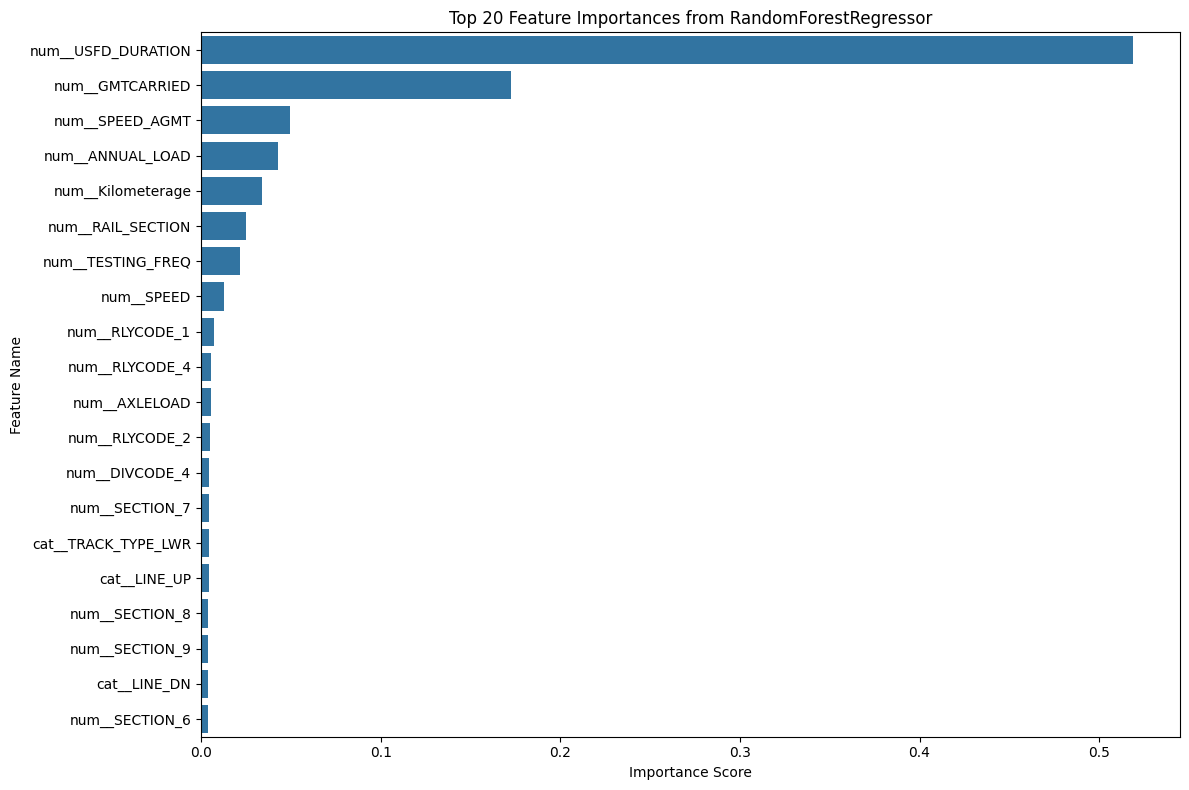

In [58]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

feature_importances = best_rf.feature_importances_

# Get feature names from the ColumnTransformer
# This method helps retrieve the names of the features after all transformations
feature_names = x_mapper.get_feature_names_out()

# Create a pandas Series for better handling
importance_series = pd.Series(feature_importances, index=feature_names)

# Sort features by importance in descending order
sorted_importance = importance_series.sort_values(ascending=False)

# Display the top 20 most important features
print("Top 20 Feature Importances:")
print(sorted_importance.head(20))

# Plotting feature importances
plt.figure(figsize=(12, 8))
sns.barplot(x=sorted_importance.head(20).values, y=sorted_importance.head(20).index)
plt.title('Top 20 Feature Importances from RandomForestRegressor')
plt.xlabel('Importance Score')
plt.ylabel('Feature Name')
plt.tight_layout()
plt.show()

Skewness of DURATION: 0.2235


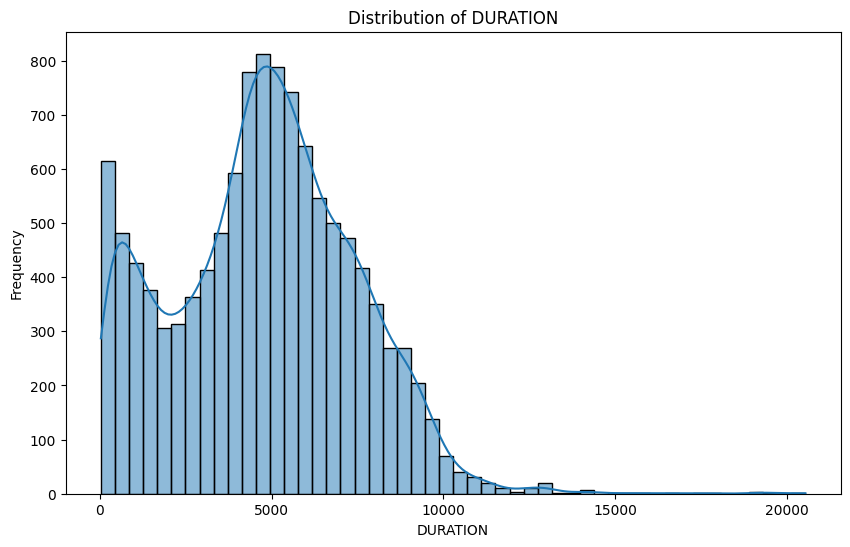

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate skewness
skewness = df_model['DURATION'].skew()
print(f"Skewness of DURATION: {skewness:.4f}")

# Visualize distribution with histogram and KDE
plt.figure(figsize=(10, 6))
sns.histplot(df_model['DURATION'], kde=True, bins=50)
plt.title('Distribution of DURATION')
plt.xlabel('DURATION')
plt.ylabel('Frequency')
plt.show()

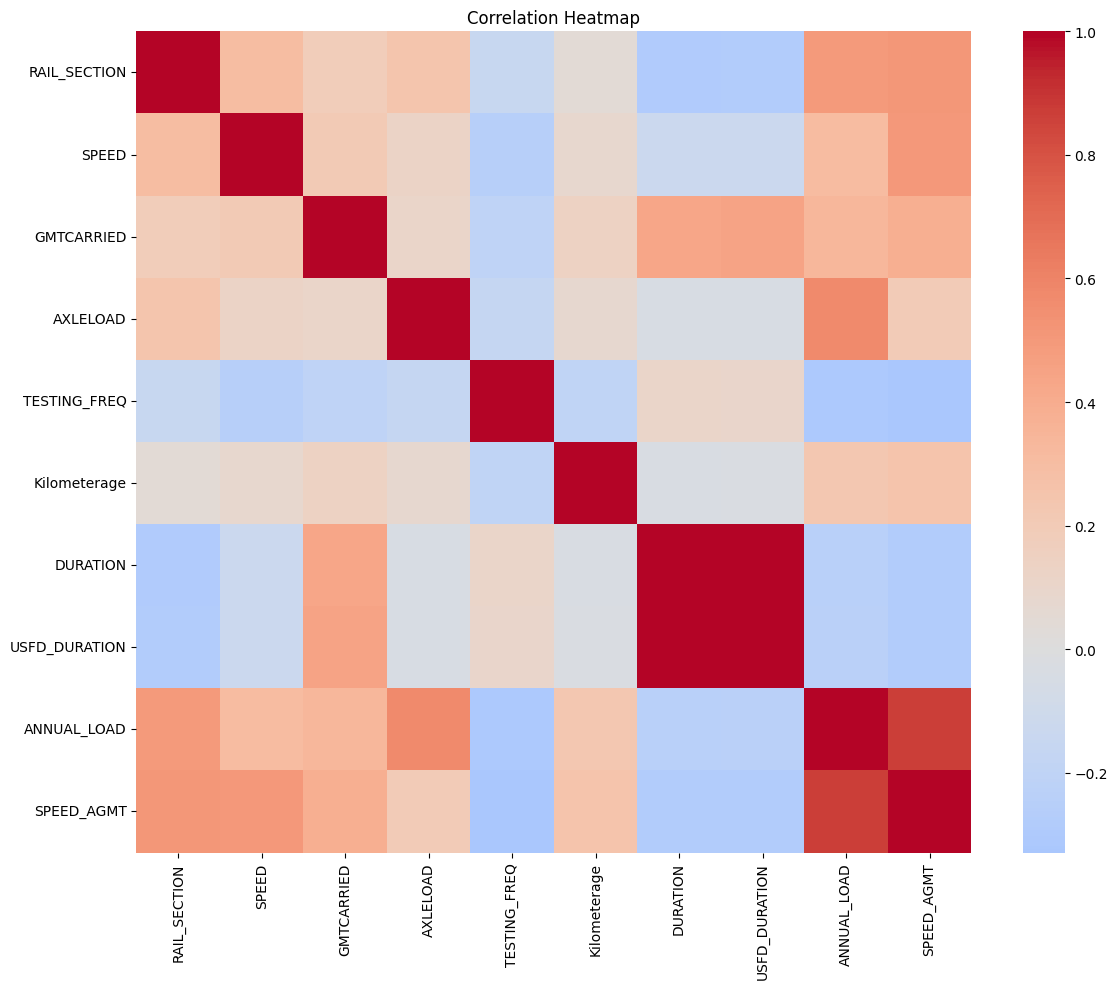

In [60]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

corr = df.select_dtypes(include=["number"]).corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

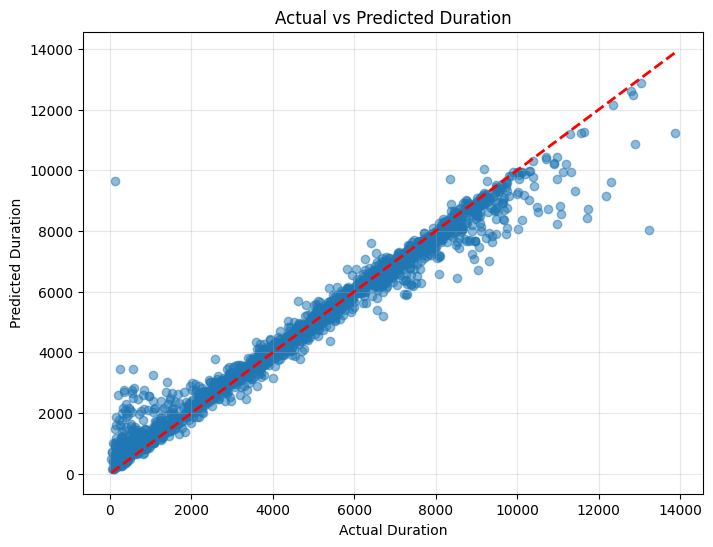

In [61]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,6))

plt.scatter(
    y_test_clean,
    y_pred,
    alpha=0.5
)

min_val = min(y_test_clean.min(), y_pred.min())
max_val = max(y_test_clean.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Duration")
plt.ylabel("Predicted Duration")
plt.title("Actual vs Predicted Duration")

plt.grid(alpha=0.3)
plt.show()

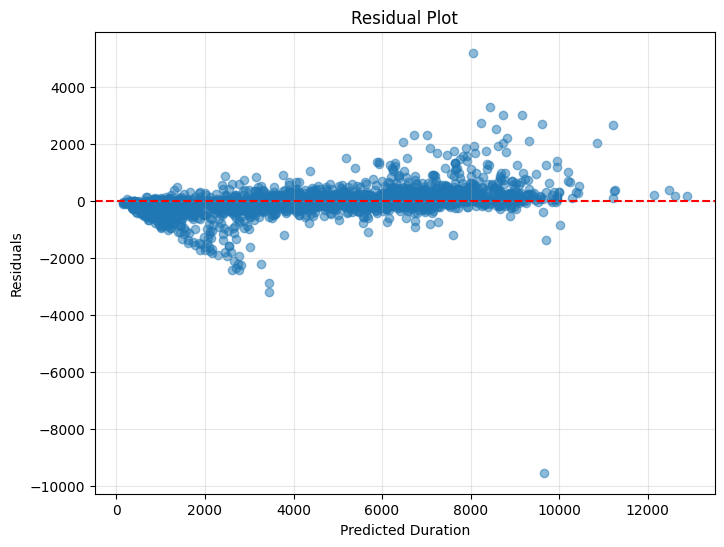

In [62]:
residuals = y_test_clean - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Duration")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.grid(alpha=0.3)
plt.show()

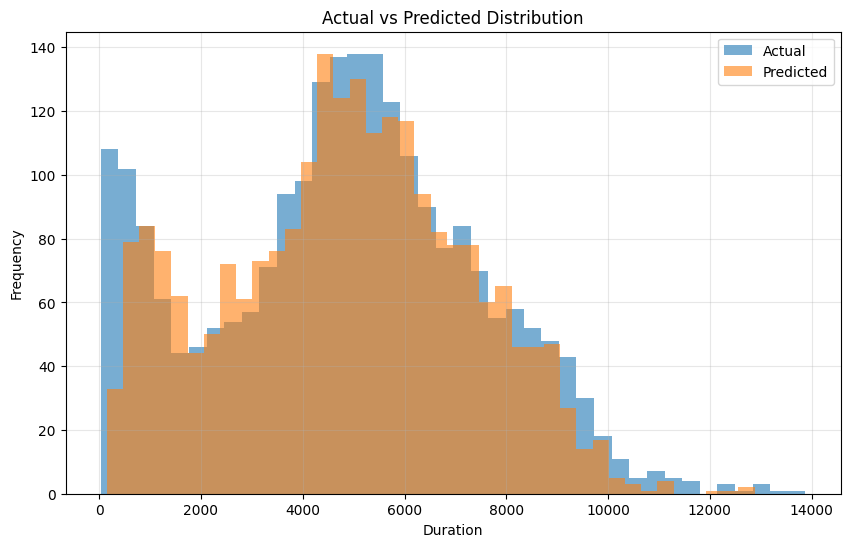

In [63]:
plt.figure(figsize=(10,6))

plt.hist(
    y_test_clean,
    bins=40,
    alpha=0.6,
    label="Actual"
)

plt.hist(
    y_pred,
    bins=40,
    alpha=0.6,
    label="Predicted"
)

plt.xlabel("Duration")
plt.ylabel("Frequency")
plt.title("Actual vs Predicted Distribution")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [64]:
import pickle

# Define the path to save the pickle file in Google Drive
save_path = "random_forest_model.pkl"

# Save the trained model to the specified path
with open(save_path, 'wb') as file:
    pickle.dump(best_rf, file)

print(f"Model saved successfully to: {save_path}")

Model saved successfully to: random_forest_model.pkl


In [65]:
import pickle

with open('binary_encoder.pkl', 'wb') as f:
    pickle.dump(bin_enc, f)

with open('ordinal_encoder.pkl', 'wb') as f:
    pickle.dump(ord_enc, f)

with open('preprocessor.pkl', 'wb') as f:
    pickle.dump(x_mapper, f)

print('binary_encoder.pkl  → saved')
print('ordinal_encoder.pkl → saved')
print('preprocessor.pkl    → saved')


binary_encoder.pkl  → saved
ordinal_encoder.pkl → saved
preprocessor.pkl    → saved


In [66]:
corr = df.corr(numeric_only=True)

print(
    corr['DURATION']
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

DURATION         1.000000
USFD_DURATION    0.996173
GMTCARRIED       0.438239
RAIL_SECTION     0.287752
SPEED_AGMT       0.286199
ANNUAL_LOAD      0.244128
SPEED            0.130211
TESTING_FREQ     0.110519
AXLELOAD         0.041132
Kilometerage     0.028989
Name: DURATION, dtype: float64
